In [ ]:
import torch
import torch.nn.functional as F
import datasets
import huggingface_hub
import matplotlib.font_manager as font_manager
import pandas as pd
import matplotlib.pyplot as plt
import transformers
import seaborn as sns
from datasets import load_dataset
from datasets import Dataset
import torch.nn as nn
from transformers import AutoModelForSequenceClassification,Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score

In [ ]:
data=load_dataset("dair-ai/emotion")

In [ ]:
data

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [ ]:
data["train"].features

{'text': Value('string'),
 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}

In [ ]:
data.set_format(type="pandas")
df_train=data["train"][:]
df_test=data["test"][:]
df_val=data["validation"][:]

In [ ]:
df_train

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3
...,...,...
15995,i just had a very brief time in the beanbag an...,0
15996,i am now turning and i feel pathetic that i am...,0
15997,i feel strong and good overall,1
15998,i feel like this was such a rude comment and i...,3


In [ ]:
df_train["label_N"]=df_train["label"].map(data["train"].features["label"].int2str)


In [ ]:
df_train

,text,label,label_N
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger
...,...,...,...
15995,i just had a very brief time in the beanbag an...,0,sadness
15996,i am now turning and i feel pathetic that i am...,0,sadness
15997,i feel strong and good overall,1,joy
15998,i feel like this was such a rude comment and i...,3,anger


<Axes: xlabel='count', ylabel='label_N'>

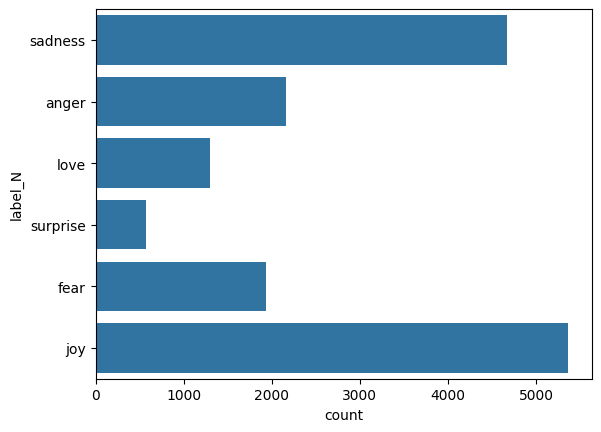

In [ ]:
sns.countplot(df_train["label_N"])

<Axes: ylabel='text'>

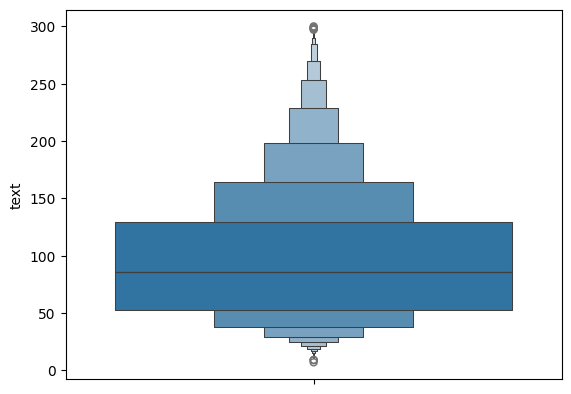

In [ ]:
sns.boxenplot(df_train["text"].str.len())

In [ ]:
data.reset_format()

In [ ]:
from transformers import AutoTokenizer
model_checkpoint="distilbert-base-uncased"
tokenizer =AutoTokenizer.from_pretrained(model_checkpoint)

In [ ]:
df_train

,text,label,label_N
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger
...,...,...,...
15995,i just had a very brief time in the beanbag an...,0,sadness
15996,i am now turning and i feel pathetic that i am...,0,sadness
15997,i feel strong and good overall,1,joy
15998,i feel like this was such a rude comment and i...,3,anger


In [ ]:
df_train.drop(columns=["label_N"],inplace=True)

In [ ]:
train=Dataset.from_pandas(df_train)
test=Dataset.from_pandas(df_test)
val=Dataset.from_pandas(df_val)

In [ ]:
train

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

In [ ]:
def token(i):
    return tokenizer(i["text"],padding=True,truncation=True)

token_trian=train.map(token, batched=True,batch_size=None).remove_columns(["text"])
token_test=test.map(token,batched=True,batch_size=None).remove_columns(["text"])
token_val=val.map(token,batched=True,batch_size=None).remove_columns(["text"])


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModel
model_checkpoint = "distilbert-base-uncased"
device = torch.device("cuda")
model = AutoModel.from_pretrained(model_checkpoint).to(device)

model=AutoModelForSequenceClassification.from_pretrained(model_checkpoint,num_labels=6).to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
args=TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64
    ,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1"
)
def eval(pred):
    logits, labels = pred
    preds = logits.argmax(axis=-1)
    f1 = f1_score(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1}


In [ ]:
print(token_trian[0].keys())

dict_keys(['label', 'input_ids', 'token_type_ids', 'attention_mask'])


In [ ]:
trainer = Trainer(
    model=model,
    args=args,
    compute_metrics=eval,
    train_dataset=token_trian,
    eval_dataset=token_val,
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.190573,0.927500,0.928089
2,0.337740,0.142789,0.938500,0.938855
3,0.337740,0.127588,0.942500,0.942536


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=750, training_loss=0.2566871566772461, metrics={'train_runtime': 343.3172, 'train_samples_per_second': 139.812, 'train_steps_per_second': 2.185, 'total_flos': 1080514292544000.0, 'train_loss': 0.2566871566772461, 'epoch': 3.0})

In [ ]:
model.save_pretrained("./final_model")
tokenizer.save_pretrained("./final_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./final_model\\tokenizer_config.json', './final_model\\tokenizer.json')